In [1]:
import os
import wfdb
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

###############################################
# Data loading and preprocessing
###############################################

# Define the path to your dataset directory
DATA_DIR = "C:/Users/M2-Winterfell/Downloads/electrocardiography-dataset-1.0.3/records500/00000"

# Function to load and extract Lead I and Lead II from a single record
def load_ecg_leads(file_path):
    try:
        # Load the record using wfdb (the file_path should be without extension)
        record = wfdb.rdrecord(file_path)
        
        # Extract Lead I and Lead II (assuming they are the first two leads)
        lead_I = record.p_signal[:, 0]  # Lead I
        lead_II = record.p_signal[:, 1]  # Lead II
        
        return lead_I, lead_II
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

# Function to load only the first n ECG records
def load_first_n_ecg_data(data_dir, n=1000):
    all_lead_I = []
    all_lead_II = []
    
    count = 0  # To keep track of the number of records loaded
    
    # Traverse through all subdirectories in records500
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc="Loading ECG files"):
            if file.endswith("_hr.dat"):  # Look for files with the _hr suffix
                # Stop loading after reaching the first n records
                if count >= n:
                    break
                
                # Construct the base filename (removing the '_hr.dat' extension)
                base_filename = file.replace("_hr.dat", "_hr")
                record_path = os.path.join(root, base_filename)
                
                # Load Lead I and Lead II
                lead_I, lead_II = load_ecg_leads(record_path)
                
                if lead_I is not None and lead_II is not None:
                    all_lead_I.append(lead_I)
                    all_lead_II.append(lead_II)
                    count += 1
                else:
                    print(f"Skipping record: {base_filename}")

        if count >= n:  # Break the outer loop as well
            break
    
    # Convert lists to NumPy arrays if data was loaded
    if all_lead_I and all_lead_II:
        all_lead_I = np.array(all_lead_I)  # Shape: (num_records, samples_per_record)
        all_lead_II = np.array(all_lead_II)  # Shape: (num_records, samples_per_record)
    else:
        all_lead_I = np.array([])
        all_lead_II = np.array([])
    
    return all_lead_I, all_lead_II

# Load only the first 1000 ECG records from records500
lead_I_data, lead_II_data = load_first_n_ecg_data(DATA_DIR, n=1000)

# Check if data was loaded successfully
if lead_I_data.size > 0 and lead_II_data.size > 0:
    print(f"Total records loaded: {lead_I_data.shape[0]}")
    print(f"Each record has {lead_I_data.shape[1]} samples per lead.")
    print("Lead I data shape:", lead_I_data.shape)
    print("Lead II data shape:", lead_II_data.shape)
else:
    print("No data was loaded.")

# Initialize the scaler for normalization
scaler = MinMaxScaler(feature_range=(-1, 1))  # ECG signals can have negative values

# Normalize the data
if lead_I_data.size > 0 and lead_II_data.size > 0:
    # Note: We are now using input = Lead II and output = Lead I
    lead_I_scaled = scaler.fit_transform(lead_I_data)
    lead_II_scaled = scaler.transform(lead_II_data)
    
    # Verify normalization
    print("Lead I scaled data range:", lead_I_scaled.min(), lead_I_scaled.max())
    print("Lead II scaled data range:", lead_II_scaled.min(), lead_II_scaled.max())
else:
    print("Skipping normalization since no data was loaded.")

# Remove stacking: now both input and output data have shape (num_records, 5000)
# Set input as Lead II and output as Lead I
input_data = lead_II_scaled  # shape: (num_records, 5000)
output_data = lead_I_scaled  # shape: (num_records, 5000)

print("Input data shape:", input_data.shape)
print("Output data shape:", output_data.shape)


Loading ECG files: 100%|██████████| 1974/1974 [00:03<00:00, 598.28it/s]


Total records loaded: 987
Each record has 5000 samples per lead.
Lead I data shape: (987, 5000)
Lead II data shape: (987, 5000)
Lead I scaled data range: -1.0 1.0000000000000004
Lead II scaled data range: -3.4331450094161955 3.042488619119878
Input data shape: (987, 5000)
Output data shape: (987, 5000)


In [2]:
###############################################
# Model definitions
###############################################

class Transpose1dLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=11, upsample=None, output_padding=1):
        super(Transpose1dLayer, self).__init__()
        self.upsample = upsample
        if self.upsample:
            self.upsample_layer = torch.nn.Upsample(scale_factor=upsample)
        reflection_pad = kernel_size // 2
        self.reflection_pad = nn.ConstantPad1d(reflection_pad, value=0)
        self.conv1d = nn.Conv1d(in_channels, out_channels, kernel_size, stride)
        self.Conv1dTrans = nn.ConvTranspose1d(in_channels, out_channels, kernel_size, stride, padding, output_padding)

    def forward(self, x):
        if self.upsample:
            return self.conv1d(self.reflection_pad(self.upsample_layer(x)))
        else:
            return self.Conv1dTrans(x)

class Transpose1dLayer_multi_input(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=11, upsample=None, output_padding=1):
        super(Transpose1dLayer_multi_input, self).__init__()
        self.upsample = upsample
        if self.upsample:
            self.upsample_layer = torch.nn.Upsample(scale_factor=upsample)
        reflection_pad = kernel_size // 2
        self.reflection_pad = nn.ConstantPad1d(reflection_pad, value=0)
        self.conv1d = nn.Conv1d(in_channels, out_channels, kernel_size, stride)
        self.Conv1dTrans = nn.ConvTranspose1d(in_channels, out_channels, kernel_size, stride, padding, output_padding)

    def forward(self, x, in_feature):
        if self.upsample:
            x = torch.cat((x, in_feature), 1)
            return self.conv1d(self.reflection_pad(self.upsample_layer(x)))
        else:
            return self.Conv1dTrans(x)

class Pulse2PulseGenerator(nn.Module):
    def __init__(self, model_size=50, num_leads=1, post_proc_filt_len=512, verbose=False, upsample=True):
        super(Pulse2PulseGenerator, self).__init__()
        self.model_size = model_size
        self.num_leads = num_leads
        self.post_proc_filt_len = post_proc_filt_len
        self.verbose = verbose
        
        stride = 4
        if upsample:
            stride = 1
            upsample = 5
        
        # Define transpose layers for multi-input handling
        self.deconv_1 = Transpose1dLayer(5 * model_size, 5 * model_size, 25, stride, upsample=upsample)
        self.deconv_2 = Transpose1dLayer_multi_input(5 * model_size * 2, 3 * model_size, 25, stride, upsample=upsample)
        self.deconv_3 = Transpose1dLayer_multi_input(3 * model_size * 2, model_size, 25, stride, upsample=upsample)
        self.deconv_5 = Transpose1dLayer_multi_input(model_size * 2, int(model_size / 2), 25, stride, upsample=2)
        self.deconv_6 = Transpose1dLayer_multi_input(int(model_size / 2) * 2, int(model_size / 5), 25, stride, upsample=upsample)
        self.deconv_7 = Transpose1dLayer(int(model_size / 5), num_leads, 25, stride, upsample=2)

        # Convolutional layers for ECG input processing
        self.conv_1 = nn.Conv1d(num_leads, int(model_size / 5), 25, stride=2, padding=25 // 2)
        self.conv_2 = nn.Conv1d(model_size // 5, model_size // 2, 25, stride=5, padding=25 // 2)
        self.conv_3 = nn.Conv1d(model_size // 2, model_size, 25, stride=2, padding=25 // 2)
        self.conv_4 = nn.Conv1d(model_size, model_size * 3, 25, stride=5, padding=25 // 2)
        self.conv_5 = nn.Conv1d(model_size * 3, model_size * 5, 25, stride=5, padding=25 // 2)
        self.conv_6 = nn.Conv1d(model_size * 5, model_size * 5, 25, stride=5, padding=25 // 2)

        if post_proc_filt_len:
            self.ppfilter1 = nn.Conv1d(num_leads, num_leads, post_proc_filt_len)

        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose1d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight.data)

    def forward(self, x):
        # Forward pass through convolution layers
        conv_1_out = F.leaky_relu(self.conv_1(x))
        conv_2_out = F.leaky_relu(self.conv_2(conv_1_out))
        conv_3_out = F.leaky_relu(self.conv_3(conv_2_out))
        conv_4_out = F.leaky_relu(self.conv_4(conv_3_out))
        conv_5_out = F.leaky_relu(self.conv_5(conv_4_out))
        x = F.leaky_relu(self.conv_6(conv_5_out))

        # Forward pass through deconvolution layers with skip connections
        x = F.relu(self.deconv_1(x))
        x = F.relu(self.deconv_2(x, conv_5_out))
        x = F.relu(self.deconv_3(x, conv_4_out))
        x = F.relu(self.deconv_5(x, conv_3_out))
        x = F.relu(self.deconv_6(x, conv_2_out))

        # Final output
        output = torch.tanh(self.deconv_7(x))

        if self.verbose:
            print(output.shape)
        return output

class Pulse2PulseDiscriminator(nn.Module):
    def __init__(self):
        super(Pulse2PulseDiscriminator, self).__init__()
        self.alpha = 0.2

        # Define convolutional layers
        # Updated first conv layer to accept 1 channel input instead of 2
        self.conv1 = nn.Conv1d(1, 64, kernel_size=25, stride=2, padding=12)  # Output: (batch_size, 64, 2500)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=25, stride=2, padding=12)  # Output: (batch_size, 128, 1250)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=25, stride=2, padding=12)  # Output: (batch_size, 256, 625)
        self.conv4 = nn.Conv1d(256, 512, kernel_size=25, stride=2, padding=12)  # Output: (batch_size, 512, 313)
        self.conv5 = nn.Conv1d(512, 1024, kernel_size=25, stride=2, padding=12)  # Output: (batch_size, 1024, 157)

        # Define fully connected layer - dynamic size based on conv outputs
        self.fc1 = nn.Linear(1024 * 157, 1)  # Adjust this size based on the convolution output

    def forward(self, x):
        # Forward pass through convolutional layers
        x = F.leaky_relu(self.conv1(x), negative_slope=self.alpha)
        x = F.leaky_relu(self.conv2(x), negative_slope=self.alpha)
        x = F.leaky_relu(self.conv3(x), negative_slope=self.alpha)
        x = F.leaky_relu(self.conv4(x), negative_slope=self.alpha)
        x = F.leaky_relu(self.conv5(x), negative_slope=self.alpha)

        # Flatten the tensor for the fully connected layer
        x = x.view(x.size(0), -1)
        # Pass through the fully connected layer and apply sigmoid
        return torch.sigmoid(self.fc1(x))

Epoch [1/30], Generator Loss: 2.9752657413482666, Discriminator Loss: 1.267946720123291
Epoch [2/30], Generator Loss: 0.6489800214767456, Discriminator Loss: 1.3066960573196411
Checkpoint saved: generator_checkpoint_epoch_2.pth


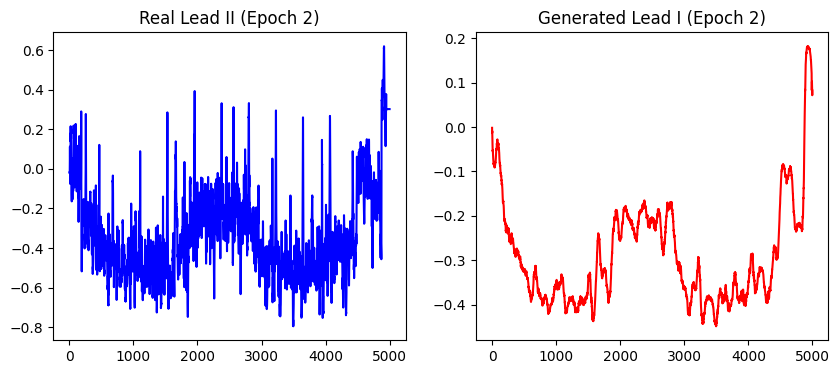

Epoch [3/30], Generator Loss: 0.5574384927749634, Discriminator Loss: 1.1778061389923096
Epoch [4/30], Generator Loss: 0.9199249148368835, Discriminator Loss: 1.2681959867477417
Checkpoint saved: generator_checkpoint_epoch_4.pth


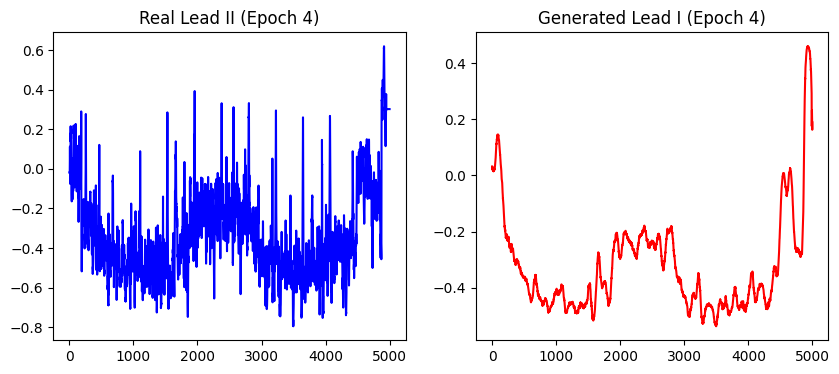

Epoch [5/30], Generator Loss: 0.7946560382843018, Discriminator Loss: 1.2725615501403809
Epoch [6/30], Generator Loss: 0.9893669486045837, Discriminator Loss: 1.1168224811553955
Checkpoint saved: generator_checkpoint_epoch_6.pth


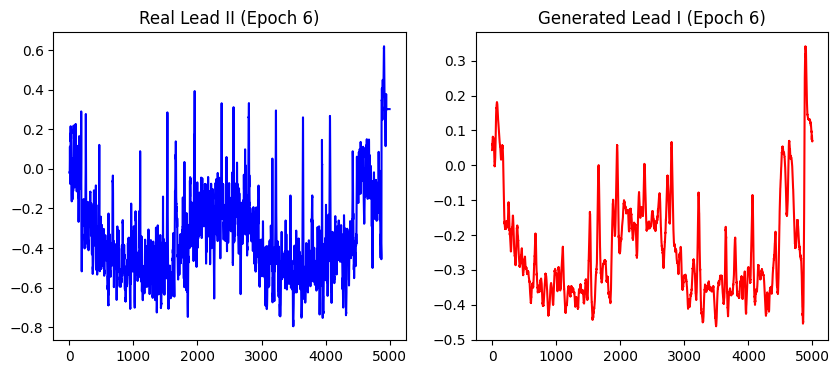

Epoch [7/30], Generator Loss: 0.9366452693939209, Discriminator Loss: 1.2184197902679443
Epoch [8/30], Generator Loss: 1.196754813194275, Discriminator Loss: 1.3197312355041504
Checkpoint saved: generator_checkpoint_epoch_8.pth


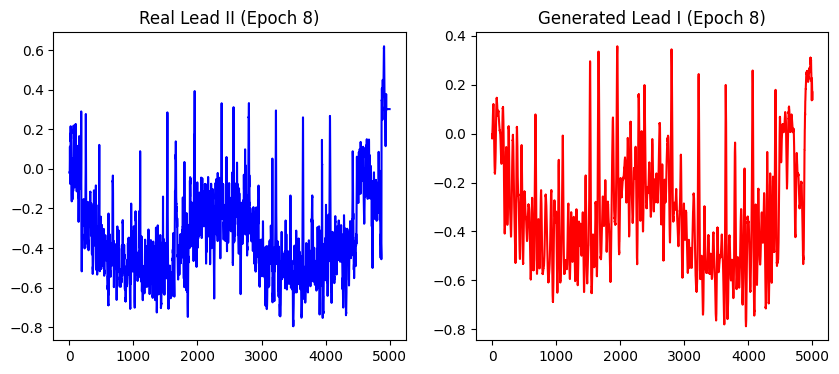

Epoch [9/30], Generator Loss: 0.9465888738632202, Discriminator Loss: 1.3118696212768555
Epoch [10/30], Generator Loss: 0.7178819179534912, Discriminator Loss: 1.3477089405059814
Checkpoint saved: generator_checkpoint_epoch_10.pth


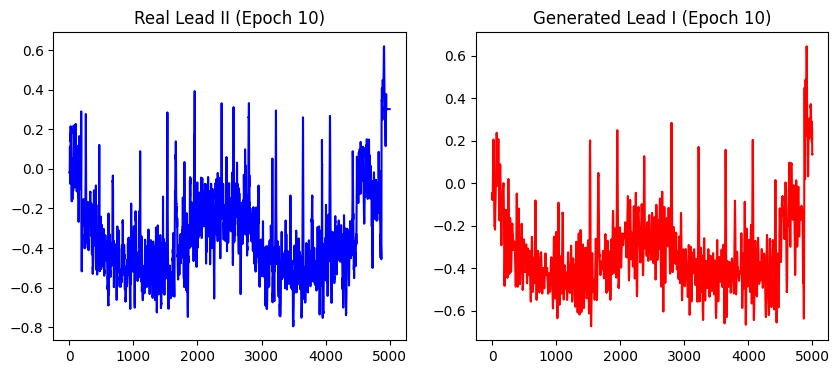

Epoch [11/30], Generator Loss: 0.9134505391120911, Discriminator Loss: 1.2024914026260376
Epoch [12/30], Generator Loss: 0.9969424605369568, Discriminator Loss: 1.2899723052978516
Checkpoint saved: generator_checkpoint_epoch_12.pth


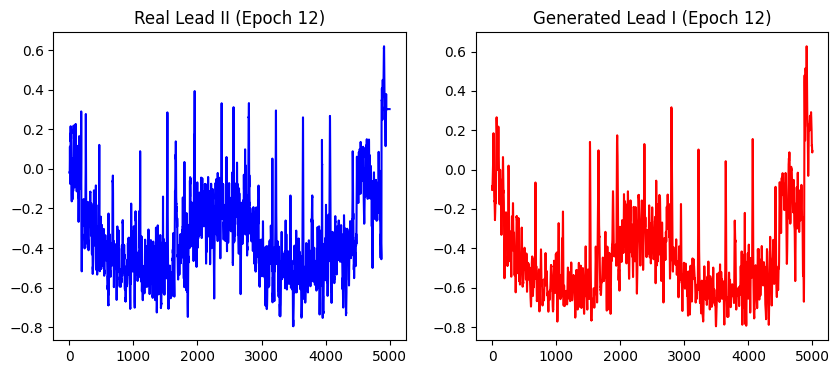

Epoch [13/30], Generator Loss: 0.8613883256912231, Discriminator Loss: 1.2489473819732666
Epoch [14/30], Generator Loss: 4.116945266723633, Discriminator Loss: 1.2156296968460083
Checkpoint saved: generator_checkpoint_epoch_14.pth


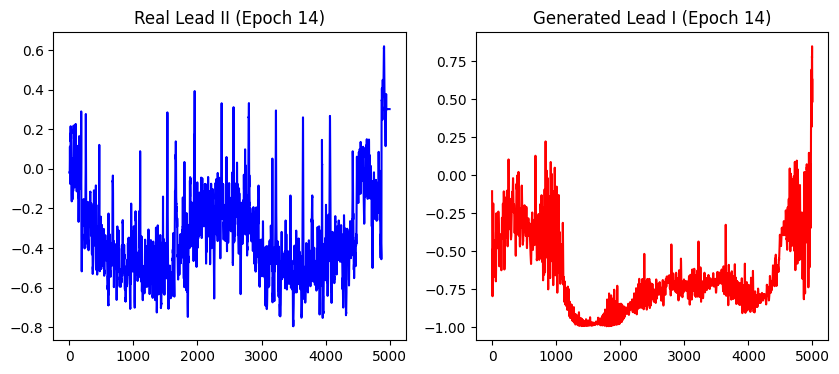

Epoch [15/30], Generator Loss: 1.2349461317062378, Discriminator Loss: 1.038367748260498
Epoch [16/30], Generator Loss: 1.0532467365264893, Discriminator Loss: 1.1223152875900269
Checkpoint saved: generator_checkpoint_epoch_16.pth


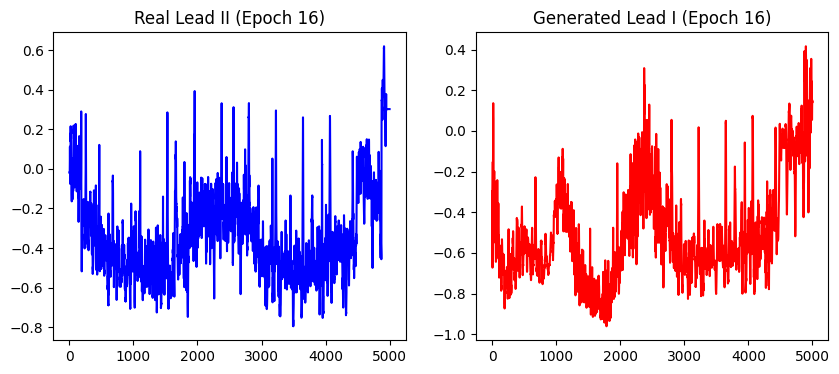

Epoch [17/30], Generator Loss: 0.8608595728874207, Discriminator Loss: 1.296280860900879
Epoch [18/30], Generator Loss: 1.070615530014038, Discriminator Loss: 1.1958134174346924
Checkpoint saved: generator_checkpoint_epoch_18.pth


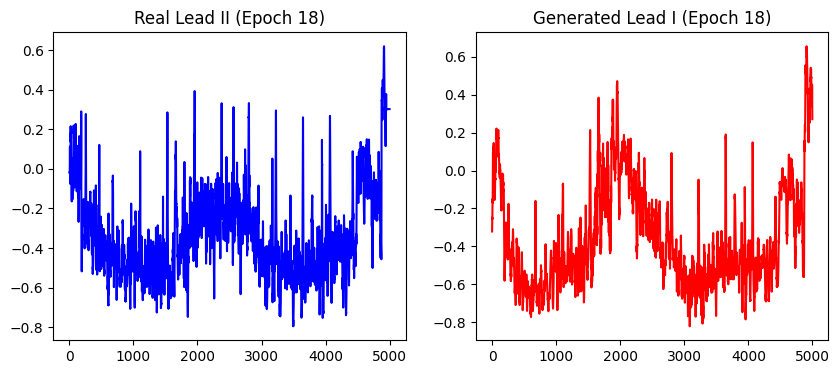

Epoch [19/30], Generator Loss: 1.3135677576065063, Discriminator Loss: 1.1983582973480225
Epoch [20/30], Generator Loss: 1.3798446655273438, Discriminator Loss: 1.1108782291412354
Checkpoint saved: generator_checkpoint_epoch_20.pth


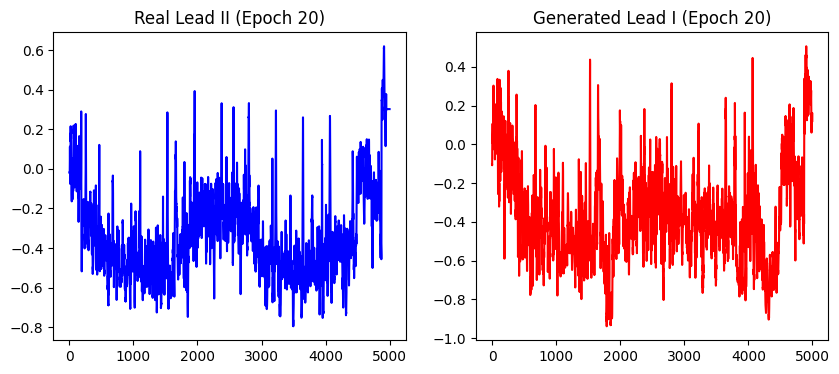

Epoch [21/30], Generator Loss: 1.4764456748962402, Discriminator Loss: 1.2007386684417725
Epoch [22/30], Generator Loss: 0.5403919816017151, Discriminator Loss: 1.414987325668335
Checkpoint saved: generator_checkpoint_epoch_22.pth


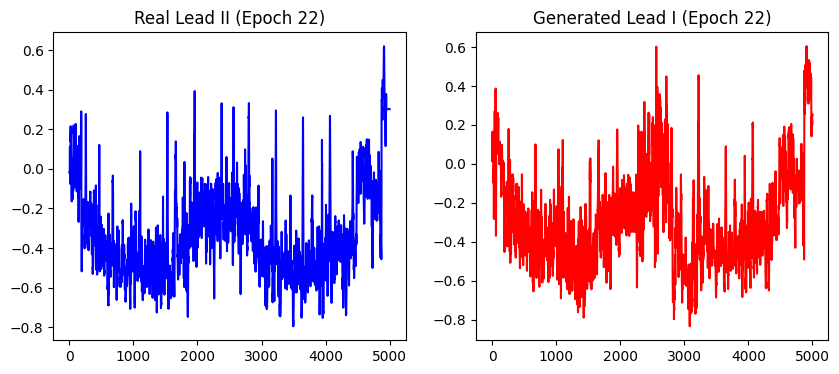

Epoch [23/30], Generator Loss: 1.533131718635559, Discriminator Loss: 1.0821627378463745
Epoch [24/30], Generator Loss: 1.3731098175048828, Discriminator Loss: 1.040550947189331
Checkpoint saved: generator_checkpoint_epoch_24.pth


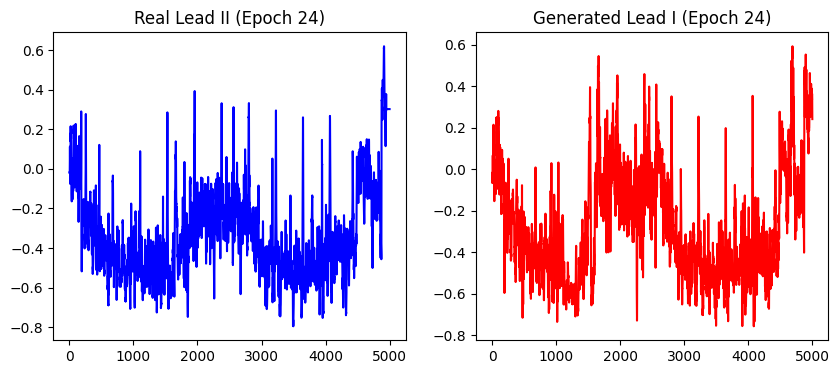

Epoch [25/30], Generator Loss: 1.2638487815856934, Discriminator Loss: 1.0675461292266846
Epoch [26/30], Generator Loss: 1.1942837238311768, Discriminator Loss: 1.0687156915664673
Checkpoint saved: generator_checkpoint_epoch_26.pth


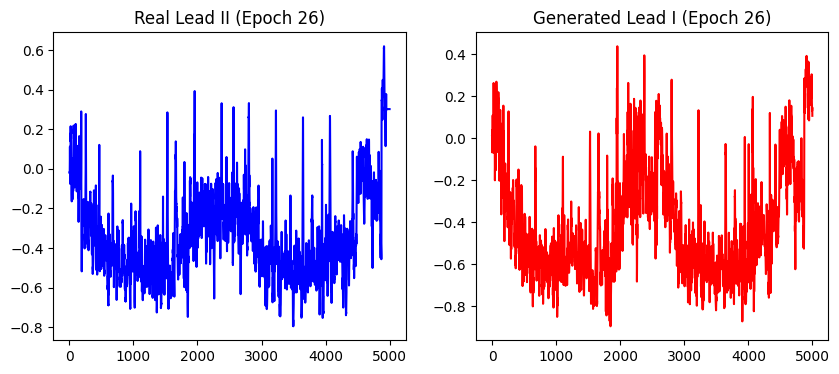

Epoch [27/30], Generator Loss: 0.9717161059379578, Discriminator Loss: 1.121180534362793
Epoch [28/30], Generator Loss: 1.3501675128936768, Discriminator Loss: 1.0665236711502075
Checkpoint saved: generator_checkpoint_epoch_28.pth


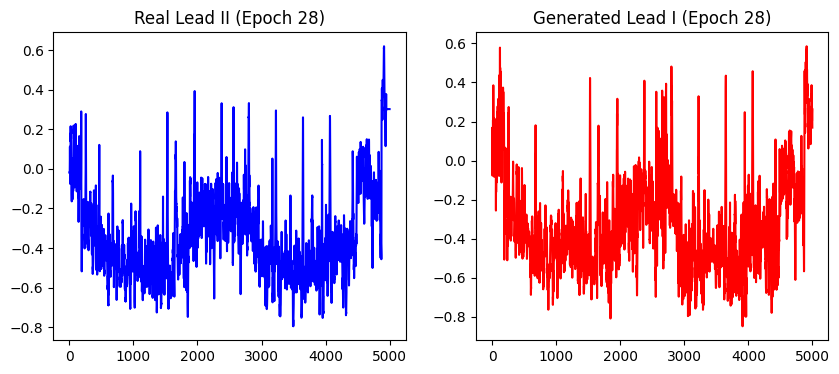

Epoch [29/30], Generator Loss: 0.8669530749320984, Discriminator Loss: 1.0929453372955322
Epoch [30/30], Generator Loss: 1.098067045211792, Discriminator Loss: 1.0483115911483765
Checkpoint saved: generator_checkpoint_epoch_30.pth


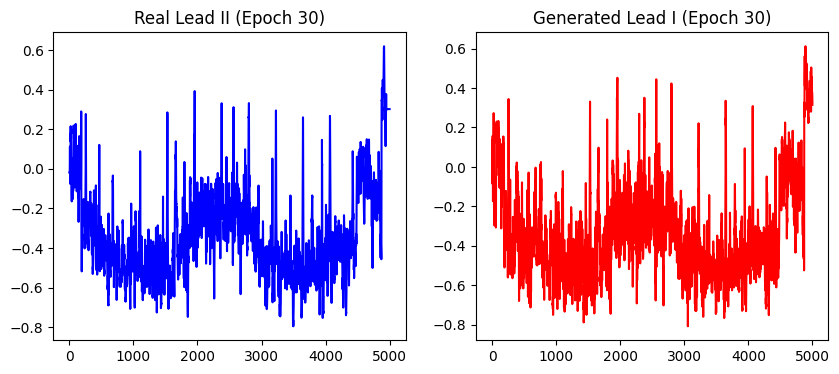

Pulse2PulseGenerator(
  (deconv_1): Transpose1dLayer(
    (upsample_layer): Upsample(scale_factor=5.0, mode='nearest')
    (reflection_pad): ConstantPad1d(padding=(12, 12), value=0)
    (conv1d): Conv1d(250, 250, kernel_size=(25,), stride=(1,))
    (Conv1dTrans): ConvTranspose1d(250, 250, kernel_size=(25,), stride=(1,), padding=(11,), output_padding=(1,))
  )
  (deconv_2): Transpose1dLayer_multi_input(
    (upsample_layer): Upsample(scale_factor=5.0, mode='nearest')
    (reflection_pad): ConstantPad1d(padding=(12, 12), value=0)
    (conv1d): Conv1d(500, 150, kernel_size=(25,), stride=(1,))
    (Conv1dTrans): ConvTranspose1d(500, 150, kernel_size=(25,), stride=(1,), padding=(11,), output_padding=(1,))
  )
  (deconv_3): Transpose1dLayer_multi_input(
    (upsample_layer): Upsample(scale_factor=5.0, mode='nearest')
    (reflection_pad): ConstantPad1d(padding=(12, 12), value=0)
    (conv1d): Conv1d(300, 50, kernel_size=(25,), stride=(1,))
    (Conv1dTrans): ConvTranspose1d(300, 50, kernel_s

In [3]:
###############################################
# Model initialization and training setup
###############################################

# Update num_leads to 1 for the new input/output shape
generator = Pulse2PulseGenerator(model_size=50, num_leads=1, post_proc_filt_len=512, verbose=False)
discriminator = Pulse2PulseDiscriminator()

# Move the models to the appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator.to(device)
discriminator.to(device)

# Optimizers for both generator and discriminator
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Loss functions for adversarial training and reconstruction
adversarial_loss_fn = nn.BCELoss()  # Binary Cross Entropy Loss for real/fake classification
reconstruction_loss_fn = nn.MSELoss()

# Ensure the data is correctly shaped: [batch_size, channels, sequence_length]
# We now add a channel dimension (1) since our data shape is (num_records, 5000)
input_data = torch.tensor(input_data, dtype=torch.float32).unsqueeze(1).to(device)   # Shape: (batch_size, 1, 5000)
output_data = torch.tensor(output_data, dtype=torch.float32).unsqueeze(1).to(device) # Shape: (batch_size, 1, 5000)

###############################################
# Training loop with checkpointing and visualization
###############################################

epochs = 30
batch_size = 32  # Adjust based on memory constraints
real_label = 0.8  # Soft label for real data
fake_label = 0.2  # Soft label for fake data

for epoch in range(epochs):
    generator.train()
    discriminator.train()

    for i in range(0, len(input_data), batch_size):
        # Get batch data
        input_lead = input_data[i:i + batch_size]      # Input: Lead II, shape: (batch_size, 1, 5000)
        real_lead = output_data[i:i + batch_size]        # Target: Lead I, shape: (batch_size, 1, 5000)

        #### Train the Discriminator ####
        d_optimizer.zero_grad()

        # Forward pass on real data
        real_preds = discriminator(real_lead)
        real_targets = torch.full_like(real_preds, real_label, device=device)
        real_loss = adversarial_loss_fn(real_preds, real_targets)

        # Forward pass on fake data
        generated_lead = generator(input_lead)
        fake_preds = discriminator(generated_lead.detach())
        fake_targets = torch.full_like(fake_preds, fake_label, device=device)
        fake_loss = adversarial_loss_fn(fake_preds, fake_targets)

        # Total discriminator loss
        d_loss = real_loss + fake_loss
        d_loss.backward()
        d_optimizer.step()

        #### Train the Generator ####
        g_optimizer.zero_grad()

        generated_lead = generator(input_lead)
        fake_preds = discriminator(generated_lead)
        g_adv_loss = adversarial_loss_fn(fake_preds, real_targets)
        g_recon_loss = reconstruction_loss_fn(generated_lead, real_lead)
        g_loss = g_adv_loss + g_recon_loss
        g_loss.backward()
        g_optimizer.step()

    # Logging after each epoch
    print(f'Epoch [{epoch + 1}/{epochs}], Generator Loss: {g_loss.item()}, Discriminator Loss: {d_loss.item()}')

    # Save checkpoint every 2 epochs
    if (epoch + 1) % 2 == 0:
        torch.save(generator.state_dict(), f'generator_checkpoint_epoch_{epoch+1}.pth')
        print(f'Checkpoint saved: generator_checkpoint_epoch_{epoch+1}.pth')

    # Visualization every 5 epochs
    if (epoch + 1) % 2 == 0:
        generator.eval()
        with torch.no_grad():
            generated_sample = generator(input_lead[:1])  # Take a single sample for visualization

        plt.figure(figsize=(10, 4))
        
        # Plot real Lead II input (since input is now Lead II)
        plt.subplot(1, 2, 1)
        plt.plot(input_lead[0][0].cpu().numpy(), color='blue')
        plt.title(f'Real Lead II (Epoch {epoch + 1})')
        
        # Plot generated Lead I output (since output is now Lead I)
        plt.subplot(1, 2, 2)
        plt.plot(generated_sample[0][0].cpu().numpy(), color='red')
        plt.title(f'Generated Lead I (Epoch {epoch + 1})')
        
        plt.savefig(f'gan_training_epoch_{epoch + 1}.png')
        plt.show()

# Switch generator to evaluation mode after training
generator.eval()

C:\Users\M2-Winterfell\AppData\Local\Temp\ipykernel_21788\3501070898.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(checkpoint_path

Saved 0.asc
Saved 1.asc
Saved 2.asc
Saved 3.asc
Saved 4.asc
Saved 5.asc
Saved 6.asc
Saved 7.asc
Saved 8.asc
Saved 9.asc
Saved 10.asc
Saved 11.asc
Saved 12.asc
Saved 13.asc
Saved 14.asc
Saved 15.asc
Saved 16.asc
Saved 17.asc
Saved 18.asc
Saved 19.asc
Saved 20.asc
Saved 21.asc
Saved 22.asc
Saved 23.asc
Saved 24.asc
Saved 25.asc
Saved 26.asc
Saved 27.asc
Saved 28.asc
Saved 29.asc
Saved 30.asc
Saved 31.asc
Saved 32.asc
Saved 33.asc
Saved 34.asc
Saved 35.asc
Saved 36.asc
Saved 37.asc
Saved 38.asc
Saved 39.asc
Saved 40.asc
Saved 41.asc
Saved 42.asc
Saved 43.asc
Saved 44.asc
Saved 45.asc
Saved 46.asc
Saved 47.asc
Saved 48.asc
Saved 49.asc
Saved 50.asc
Saved 51.asc
Saved 52.asc
Saved 53.asc
Saved 54.asc
Saved 55.asc
Saved 56.asc
Saved 57.asc
Saved 58.asc
Saved 59.asc
Saved 60.asc
Saved 61.asc
Saved 62.asc
Saved 63.asc
Saved 64.asc
Saved 65.asc
Saved 66.asc
Saved 67.asc
Saved 68.asc
Saved 69.asc
Saved 70.asc
Saved 71.asc
Saved 72.asc
Saved 73.asc
Saved 74.asc
Saved 75.asc
Saved 76.asc
Saved 77.

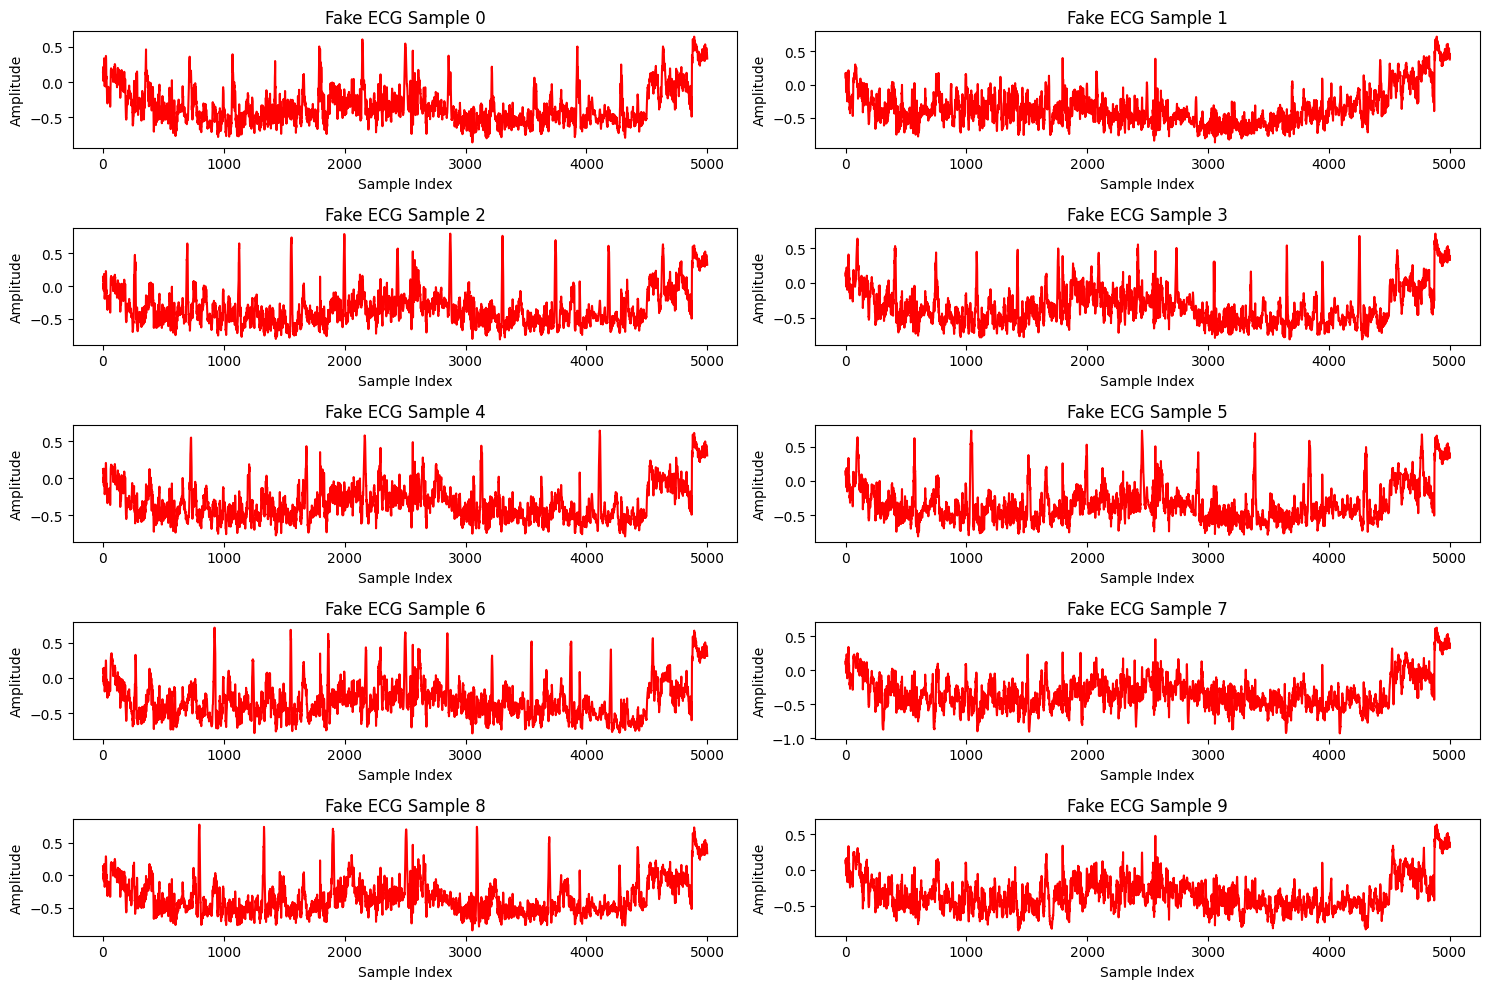

In [ ]:
###############################################
# Generation of fake ECG data and saving as .asc files
###############################################

# Optionally, you can load a specific checkpoint before generation:
checkpoint_path = 'checkpoints/generator_checkpoint_epoch_30.pth'
generator.load_state_dict(torch.load(checkpoint_path))
generator.eval()

# Generate 1000 fake ECG samples (using random samples from input data as seed)
num_fake_samples = 1000
fake_samples_for_plot = []  # List to store 10 samples for visualization

generator.eval()
for i in range(num_fake_samples):
    # Randomly select an index from the training input (with replacement)
    idx = np.random.randint(0, input_data.size(0))
    sample_input = input_data[idx:idx+1]  # Shape: (1, 1, 5000)
    with torch.no_grad():
        generated_sample = generator(sample_input)
    # Remove batch and channel dimensions to get a 1D array of length 5000
    generated_sample = generated_sample.cpu().numpy().squeeze()
    # Save the generated ECG data in .asc format, naming files from 0.asc to 999.asc
    np.savetxt(f'{i}.asc', generated_sample)
    print(f'Saved {i}.asc')
    
    # Collect first 10 samples for visualization
    if i < 10:
        fake_samples_for_plot.append(generated_sample)

print("Generation of fake ECG data complete.")

# Visualization: Plot the 10 collected fake ECG samples
plt.figure(figsize=(15, 10))
for j, sample in enumerate(fake_samples_for_plot):
    plt.subplot(5, 2, j+1)
    plt.plot(sample, color='red')
    plt.title(f'Fake ECG Sample {j}')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()